**Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
import joblib

warnings.filterwarnings('ignore')
os.makedirs('../data/processed', exist_ok=True)
%matplotlib inline

from docplex.mp.model import Model
import xgboost as xgb
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Load processed data
df = pd.read_csv('../data/processed/application_processed.csv')
X  = df.drop(columns=['TARGET'])
y  = df['TARGET']

# Clean column names
X.columns = [str(c).replace('[','').replace(']','').replace('<','')
             for c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Test set (loan applications to evaluate): {X_test.shape}")

Test set (loan applications to evaluate): (61503, 83)


**Retrain Model & sScore All Applicants**

In [2]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Score test applicants
default_prob = xgb_model.predict_proba(X_test)[:, 1]
repay_prob   = 1 - default_prob

print(f"Scored {len(default_prob):,} applicants")
print(f"Mean default probability : {default_prob.mean():.2%}")
print(f"Mean repay probability   : {repay_prob.mean():.2%}")

Scored 61,503 applicants
Mean default probability : 38.58%
Mean repay probability   : 61.42%


**Build Loan Portfolio DataFrame**

In [3]:
# Simulate realistic loan amounts from the test set
np.random.seed(RANDOM_STATE)

portfolio_df = pd.DataFrame({
    'applicant_id'   : range(len(X_test)),
    'default_prob'   : default_prob,
    'repay_prob'     : repay_prob,
    'loan_amount'    : X_test['AMT_CREDIT'].values,
    'loan_term'      : X_test['LOAN_TERM_MONTHS'].values.clip(6, 360),
    'income'         : X_test['AMT_INCOME_TOTAL'].values,
}).reset_index(drop=True)

# Expected return: assume 12% annual interest rate
ANNUAL_RATE = 0.12
portfolio_df['monthly_rate']    = ANNUAL_RATE / 12
portfolio_df['expected_return'] = (
    portfolio_df['repay_prob'] *
    portfolio_df['loan_amount'] *
    portfolio_df['monthly_rate'] *
    portfolio_df['loan_term']
)

# Expected loss given default (assume 40% recovery)
LGD = 0.60
portfolio_df['expected_loss'] = (
    portfolio_df['default_prob'] *
    portfolio_df['loan_amount'] *
    LGD
)

# Risk-adjusted return
portfolio_df['risk_adj_return'] = (
    portfolio_df['expected_return'] - portfolio_df['expected_loss']
)

# Filter — only consider applicants with positive risk-adjusted return
portfolio_df = portfolio_df[portfolio_df['risk_adj_return'] > 0].reset_index(drop=True)

print(f"Viable applicants (positive risk-adj return): {len(portfolio_df):,}")
print(f"\nPortfolio statistics:")
print(portfolio_df[['loan_amount','expected_return',
                     'expected_loss','risk_adj_return']].describe().round(2))

Viable applicants (positive risk-adj return): 20,976

Portfolio statistics:
       loan_amount  expected_return  expected_loss  risk_adj_return
count     20976.00         20976.00       20976.00         20976.00
mean     730976.01        163980.59       84401.04         79579.55
std      472836.16        139562.12       70193.23        103466.96
min       45000.00          3658.25         764.55             6.22
25%      318390.75         52724.13       28270.02         14308.60
50%      675000.00        131240.43       66744.48         42142.54
75%     1029314.25        231480.30      121616.54        105102.71
max     4050000.00       1552631.49      542706.83       1427357.61


**CPLEX Optimization**

In [4]:
# Problem: select which loans to approve to maximize
# total risk-adjusted return subject to capital constraints

# Use a manageable subset for the solver
N = 500  # applicants to optimize over
subset = portfolio_df.sample(N, random_state=RANDOM_STATE).reset_index(drop=True)

# Parameters
CAPITAL_BUDGET     = 10_000_000  # increase to $10M
MAX_SINGLE_LOAN    = 0.10        # relax to 10% of budget
MAX_DEFAULT_PROB   = 0.50        # relax PD threshold to 50%
MIN_PORTFOLIO_SIZE = 20          # reduce minimum to 20 loans

mdl = Model(name='CreditPortfolioOptimization')

# Decision variables: binary — approve (1) or reject (0)
x = mdl.binary_var_list(N, name='approve')

# Objective: maximize total risk-adjusted return
mdl.maximize(
    mdl.sum(x[i] * subset.loc[i, 'risk_adj_return'] for i in range(N))
)

# Constraint 1: total capital deployed <= budget
mdl.add_constraint(
    mdl.sum(x[i] * subset.loc[i, 'loan_amount'] for i in range(N))
    <= CAPITAL_BUDGET,
    ctname='capital_budget'
)

# Constraint 2: no single loan exceeds 5% of budget (concentration risk)
for i in range(N):
    mdl.add_constraint(
        x[i] * subset.loc[i, 'loan_amount'] <= MAX_SINGLE_LOAN * CAPITAL_BUDGET,
        ctname=f'concentration_{i}'
    )

# Constraint 3: reject high-risk applicants (PD > 35%)
for i in range(N):
    if subset.loc[i, 'default_prob'] > MAX_DEFAULT_PROB:
        mdl.add_constraint(x[i] == 0, ctname=f'max_pd_{i}')

# Constraint 4: minimum portfolio diversification
mdl.add_constraint(
    mdl.sum(x[i] for i in range(N)) >= MIN_PORTFOLIO_SIZE,
    ctname='min_portfolio_size'
)

print(f"Model: {mdl.number_of_variables} variables, "
      f"{mdl.number_of_constraints} constraints")

# Solve
solution = mdl.solve(log_output=False)

if solution:
    print(f"Solver status : {mdl.solve_status}")
    print(f"Optimal value : ${solution.objective_value:,.2f}")
else:
    print("No solution found — check constraints")

Model: 500 variables, 502 constraints
-- cannot find parameters matching version: 22.2.0.0, using: 22.1.1.0
Solver status : JobSolveStatus.OPTIMAL_SOLUTION
Optimal value : $2,240,953.85


**Analyze Solution**

In [5]:
if solution:
    # Extract approved loans
    approved = [i for i in range(N) if x[i].solution_value > 0.5]
    rejected = [i for i in range(N) if x[i].solution_value < 0.5]

    approved_df = subset.loc[approved].copy()
    rejected_df = subset.loc[rejected].copy()

    total_capital    = approved_df['loan_amount'].sum()
    total_return     = approved_df['risk_adj_return'].sum()
    avg_default_prob = approved_df['default_prob'].mean()
    total_exp_loss   = approved_df['expected_loss'].sum()

    print("=" * 55)
    print("PORTFOLIO OPTIMIZATION RESULTS")
    print("=" * 55)
    print(f"Loans approved          : {len(approved_df):,} / {N}")
    print(f"Loans rejected          : {len(rejected_df):,} / {N}")
    print(f"Capital deployed        : ${total_capital:,.0f} / ${CAPITAL_BUDGET:,.0f}")
    print(f"Capital utilization     : {total_capital/CAPITAL_BUDGET:.1%}")
    print(f"Total risk-adj return   : ${total_return:,.0f}")
    print(f"Avg default probability : {avg_default_prob:.2%}")
    print(f"Expected portfolio loss : ${total_exp_loss:,.0f}")
    print(f"Return on capital       : {total_return/total_capital:.2%}")
    print("=" * 55)

PORTFOLIO OPTIMIZATION RESULTS
Loans approved          : 20 / 500
Loans rejected          : 480 / 500
Capital deployed        : $9,999,945 / $10,000,000
Capital utilization     : 100.0%
Total risk-adj return   : $2,240,954
Avg default probability : 9.70%
Expected portfolio loss : $633,131
Return on capital       : 22.41%


**Visualize Portfolio**

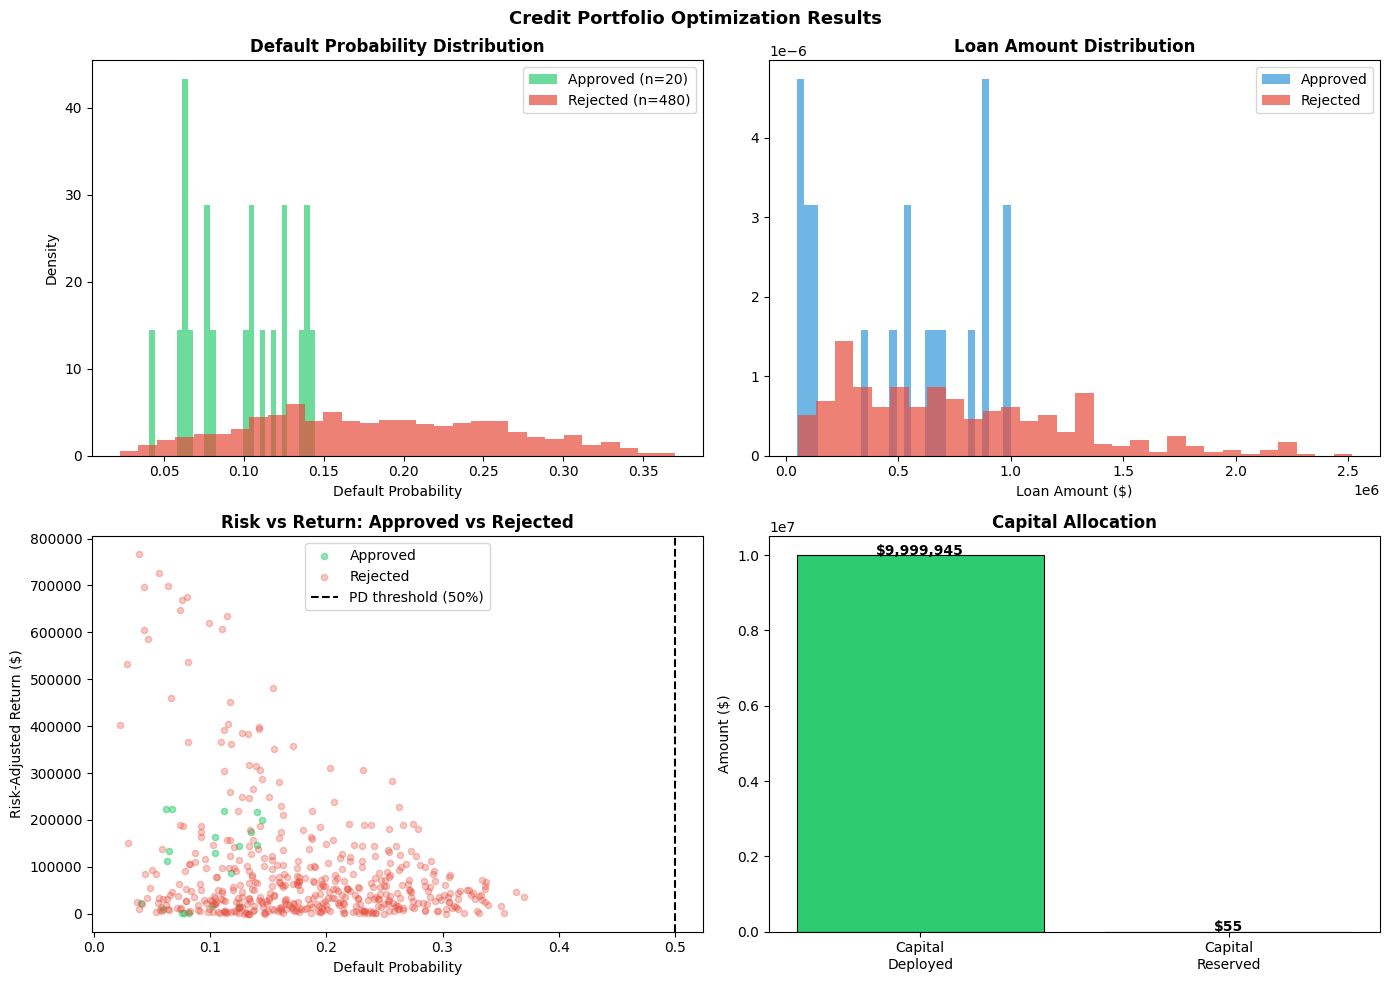

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Approved vs Rejected by default probability
axes[0,0].hist(approved_df['default_prob'], bins=30, alpha=0.7,
               color='#2ecc71', label=f'Approved (n={len(approved_df)})', density=True)
axes[0,0].hist(rejected_df['default_prob'], bins=30, alpha=0.7,
               color='#e74c3c', label=f'Rejected (n={len(rejected_df)})', density=True)
axes[0,0].set_xlabel('Default Probability')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Default Probability Distribution', fontweight='bold')
axes[0,0].legend()

# 2. Loan amount distribution
axes[0,1].hist(approved_df['loan_amount'], bins=30, alpha=0.7,
               color='#3498db', label='Approved', density=True)
axes[0,1].hist(rejected_df['loan_amount'], bins=30, alpha=0.7,
               color='#e74c3c', label='Rejected', density=True)
axes[0,1].set_xlabel('Loan Amount ($)')
axes[0,1].set_title('Loan Amount Distribution', fontweight='bold')
axes[0,1].legend()

# 3. Risk-adjusted return scatter
axes[1,0].scatter(approved_df['default_prob'], approved_df['risk_adj_return'],
                  alpha=0.5, color='#2ecc71', s=20, label='Approved')
axes[1,0].scatter(rejected_df['default_prob'], rejected_df['risk_adj_return'],
                  alpha=0.3, color='#e74c3c', s=20, label='Rejected')
axes[1,0].axvline(MAX_DEFAULT_PROB, color='black', linestyle='--',
                  linewidth=1.5, label=f'PD threshold ({MAX_DEFAULT_PROB:.0%})')
axes[1,0].set_xlabel('Default Probability')
axes[1,0].set_ylabel('Risk-Adjusted Return ($)')
axes[1,0].set_title('Risk vs Return: Approved vs Rejected', fontweight='bold')
axes[1,0].legend()

# 4. Capital allocation summary
categories = ['Capital\nDeployed', 'Capital\nReserved']
values     = [total_capital, CAPITAL_BUDGET - total_capital]
colors     = ['#2ecc71', '#bdc3c7']
bars = axes[1,1].bar(categories, values, color=colors,
                      edgecolor='black', linewidth=0.8)
axes[1,1].set_title('Capital Allocation', fontweight='bold')
axes[1,1].set_ylabel('Amount ($)')
for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 10000,
                   f'${val:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Credit Portfolio Optimization Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/14_portfolio_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

**Save results**

In [7]:
approved_df.to_csv('../data/processed/approved_loans.csv', index=False)
rejected_df.to_csv('../data/processed/rejected_loans.csv', index=False)

print("Saved:")
print("  → data/processed/approved_loans.csv")
print("  → data/processed/rejected_loans.csv")
print("\nNext: RAG Agentic Explainability Layer")

Saved:
  → data/processed/approved_loans.csv
  → data/processed/rejected_loans.csv

Next: RAG Agentic Explainability Layer
